# Figures 3 & 4: Nino3.4 SST Skill (correlation & nRMSE) & DJF Time Series

In [45]:
%load_ext autoreload
%autoreload 2
import os
import xarray as xr 
import numpy as np  
import cftime
import copy
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import xesmf as xe
import xskillscore as xs
%matplotlib inline

# import ESP-Lab modules
#from esp_lab import data_access_smyle.py as data_access
from esp_lab import data_access_e3sm as data_access
from esp_lab import data_access_obs as obs_access
from esp_lab import stats

# import plotting and other utilities from esp_lab.utils (formerly SMYLEutils)
from esp_lab.utils import spatial_utils as spatial
from esp_lab.utils import calendar_utils as cal
from esp_lab.utils import mapplot_utils as maps
from esp_lab.utils import colorbar_utils as cbars
from esp_lab.utils import regrid_utils as regrid

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import dask
from dask.distributed import (
    wait,
    get_client
)
dask.__version__

'2026.3.0'

## Create Dask Cluster

In [47]:
def get_ClusterClient(cluster_type='local', workers=4):
    """
    Create a Dask Cluster and Client based on the machine environment.
    cluster_type options: 'local', 'casper_pbs', 'slurm'
    """
    import dask
    from dask.distributed import Client
    
    # Optional global dask config
    dask.config.set({'array.slicing.split_large_chunks': True})

    if cluster_type == 'casper_pbs':
        # Specific to NCAR's Casper machine
        from dask_jobqueue import PBSCluster
        cluster = PBSCluster(
            cores=1,
            memory='20GB',
            processes=1,
            queue='casper',
            resource_spec='select=1:ncpus=1:mem=20GB',
            project='NCGD0011',
            walltime='02:00:00',
            interface='ib0'
        )
        dask.config.set({
            'distributed.dashboard.link':
            'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'
        })
        client = Client(cluster)
        cluster.scale(30)
        
    elif cluster_type == 'slurm':
        from dask_jobqueue import SLURMCluster
        cluster = SLURMCluster(
            cores=4,
            processes=1,
            memory="16GB",
            walltime="02:00:00"
            # queue="compute", 
            # project="my_project" 
        )
        client = Client(cluster)
        cluster.scale(workers)
        
    elif cluster_type == 'local':
        from dask.distributed import LocalCluster
        cluster = LocalCluster(n_workers=workers)
        client = Client(cluster)
        
    else:
        raise ValueError(f"Unknown cluster_type: {cluster_type}")

    return cluster, client

# Set this to 'casper_pbs' when on NCAR Casper, or 'local' on your PC
machine_env = os.environ.get('CLUSTER_TYPE', 'local') 

try:
    client = get_client()
    print(client)
except ValueError:
    print("No active client")
try:
    client.close()
    cluster.close()
except:
    pass

cluster, client = get_ClusterClient(cluster_type=machine_env, workers=30)

<Client: 'tcp://127.0.0.1:38197' processes=30 threads=270, memory=502.97 GiB>


/global/homes/z/zhan391/.conda/envs/e3sm_analysis/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 41445 instead
  warnings.warn(


In [48]:
cluster

LocalCluster(5ac266d2, 'tcp://127.0.0.1:46313', workers=30, threads=270, memory=502.97 GiB)

### Read in POP monthly SST field using I/O functions; Convert to seasonal mean

In [67]:
%%time
# E3SM-May TS data
# process all 10 ensemble members, all start dates from 1980-2014:
field = "TS"
data_dir = "/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D"
case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"
case_nens = 10    # total ensemble members for each lead-time simulation
case_nlead = 24   # total simulation months starting from each init
engine = "netcdf4" #"netcdf4" #or scipy for older format 

lead_years = np.arange(1980, 1984, 1)
lead_month = 5 # or [5, 11]
members = [f"EN{i:02d}" for i in range(case_nens)]

realm = "atm"         # post-processed model component (atm, lnd, rof, ocean, sea-ice)
grid = "180x360_aave" # post-processed grid (e3sm_diags)
freq = "monthly"      # model output frequency 
ts_split = "2yr"      # post-processed # of years in each file 

# all ensemble members are present for an initialization
require_all_members = True
verify_field_name = True
verify_coverage = True

init_tags = data_access.build_init_tags(lead_years, lead_month)
chunk = {}
print(init_tags)
print(case_prefix)

e3smle05 = data_access.get_monthly_data(
    data_dir=data_dir,
    case_prefix=case_prefix,
    members=members,
    init_tags=init_tags,
    field=field,
    nlead=case_nlead,
    chunks=chunk,
    realm=realm,
    grid=grid,
    freq=freq,
    ts_split=ts_split,
    require_all_members=require_all_members,
    verify_field_name=verify_field_name,
    verify_coverage=verify_coverage,
    engine=engine,
)

# convert unit from K to degC 
if field == "TS":
    e3smle05[field] = e3smle05[field] - 273.15
    e3smle05[field].attrs["units"] = "degC"

    print("=== Data range after conversion ===")
    print("min:", float(e3smle05[field].min()))
    print("max:", float(e3smle05[field].max()))

e3smle05.nbytes / 1e9  # GB

# debug 
print(e3smle05)
print(e3smle05.dims)
print(e3smle05.Y.values)
print(e3smle05.L.values[:5], e3smle05.L.values[-5:])
print(e3smle05.time.isel(Y=0, L=slice(0, 3)).values)


['1980050100', '1981050100', '1982050100', '1983050100']
WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL
=== Data range after conversion ===
min: -76.33110046386719
max: 44.407562255859375
<xarray.Dataset> Size: 249MB
Dimensions:  (Y: 4, L: 24, M: 10, lat: 180, lon: 360)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * Y        (Y) <U10 160B '1980050100' '1981050100' '1982050100' '1983050100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    time     (Y, L) object 768B dask.array<chunksize=(1, 24), meta=np.ndarray>
    TS       (Y, L, M, lat, lon) float32 249MB dask.array<chunksize=(1, 24, 1, 180, 360), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'Y': 4, 'L': 24, 'M': 10, 'lat': 180, 'lon': 360})
['1980050100' '1981050100' '

In [68]:
%%time
# E3SM-Nov TS data
# process all 10 ensemble members, all start dates from 1980-2014:
field = "TS"
data_dir = "/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D"
case_prefix = "WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL"
case_nens = 10    # total ensemble members for each lead-time simulation
case_nlead = 24   # total simulation months starting from each init
engine = "netcdf4" # or scipy for older format 

lead_years = np.arange(1980, 1984, 1)
lead_month = 11 # or [5, 11]
members = [f"EN{i:02d}" for i in range(case_nens)]

realm = "atm"         # post-processed model component (atm, lnd, rof, ocean, sea-ice)
grid = "180x360_aave" # post-processed grid (e3sm_diags)
freq = "monthly"      # model output frequency 
ts_split = "2yr"      # post-processed # of years in each file 

# all ensemble members are present for an initialization
require_all_members = True
verify_field_name = True
verify_coverage = True

init_tags = data_access.build_init_tags(lead_years, lead_month)
chunk = {}
print(init_tags)
print(case_prefix)

e3smle11 = data_access.get_monthly_data(
    data_dir=data_dir,
    case_prefix=case_prefix,
    members=members,
    init_tags=init_tags,
    field=field,
    nlead=case_nlead,
    chunks=chunk,
    realm=realm,
    grid=grid,
    freq=freq,
    ts_split=ts_split,
    require_all_members=require_all_members,
    verify_field_name=verify_field_name,
    verify_coverage=verify_coverage,
    engine = engine
)

# convert unit from K to degC 
if field == "TS":
    e3smle11[field] = e3smle11[field] - 273.15
    e3smle11[field].attrs["units"] = "degC"

    print("=== Data range after conversion ===")
    print("min:", float(e3smle11[field].min()))
    print("max:", float(e3smle11[field].max()))

e3smle11.nbytes / 1e9  # GB

# debug 
print(e3smle11)
print(e3smle11.dims)
print(e3smle11.Y.values)
print(e3smle11.L.values[:5], e3smle11.L.values[-5:])
print(e3smle11.time.isel(Y=0, L=slice(0, 3)).values)

['1980110100', '1981110100', '1982110100', '1983110100']
WCYCL20TR_ne30pg2_r05_IcoswISC30E3r5_JRA55_FOSIRL
=== Data range after conversion ===
min: -76.36561584472656
max: 43.97222900390625
<xarray.Dataset> Size: 249MB
Dimensions:  (Y: 4, L: 24, M: 10, lat: 180, lon: 360)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * Y        (Y) <U10 160B '1980110100' '1981110100' '1982110100' '1983110100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    time     (Y, L) object 768B dask.array<chunksize=(1, 24), meta=np.ndarray>
    TS       (Y, L, M, lat, lon) float32 249MB dask.array<chunksize=(1, 24, 1, 180, 360), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'Y': 4, 'L': 24, 'M': 10, 'lat': 180, 'lon': 360})
['1980110100' '1981110100' '1

In [69]:
%%time
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

outname = f"E3SMLE05_{field}_N{case_nens:02d}_M{case_nlead:02d}_seas.nc"
outfile = os.path.join(outdir, outname)
force_rewrite = True

if os.path.exists(outfile) and not force_rewrite:
    e3smle05_seas = xr.open_dataset(outfile)
else:
    if os.path.exists(outfile):
        os.remove(outfile)

    e3smle05_seas = cal.mon_to_seas_dask(e3smle05).persist()
    daskout = wait(e3smle05_seas)

    e3smle05_seas.to_netcdf(outfile)

# debug 
print(e3smle05_seas)
print(e3smle05_seas.dims)
print(e3smle05_seas.Y.values)
print(e3smle05_seas.L.values[:5], e3smle05_seas.L.values[-5:])
print(e3smle05_seas.time.isel(Y=0, L=slice(0, 3)).values)

<xarray.Dataset> Size: 83MB
Dimensions:  (lon: 360, lat: 180, L: 8, Y: 4, M: 10)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * Y        (Y) <U10 160B '1980050100' '1981050100' '1982050100' '1983050100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    TS       (Y, L, M, lat, lon) float32 83MB dask.array<chunksize=(1, 8, 1, 90, 180), meta=np.ndarray>
    time     (Y, L) object 256B dask.array<chunksize=(1, 8), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'lon': 360, 'lat': 180, 'L': 8, 'Y': 4, 'M': 10})
['1980050100' '1981050100' '1982050100' '1983050100']
[ 3  6  9 12 15] [12 15 18 21 24]
[cftime.DatetimeNoLeap(1980, 7, 15, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1980, 10, 15, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1981, 1, 1

In [70]:
%%time
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

outname = f"E3SMLE11_{field}_N{case_nens:02d}_M{case_nlead:02d}_seas.nc"
outfile = os.path.join(outdir, outname)
force_rewrite = True

if os.path.exists(outfile) and not force_rewrite:
    e3smle11_seas = xr.open_dataset(outfile)
else:
    if os.path.exists(outfile):
        os.remove(outfile)

    e3smle11_seas = cal.mon_to_seas_dask(e3smle11).persist()
    daskout = wait(e3smle11_seas)

    e3smle11_seas.to_netcdf(outfile)

# debug 
print(e3smle11_seas)
print(e3smle11_seas.dims)
print(e3smle11_seas.Y.values)
print(e3smle11_seas.L.values[:5], e3smle11_seas.L.values[-5:])
print(e3smle11_seas.time.isel(Y=0, L=slice(0, 3)).values)

<xarray.Dataset> Size: 83MB
Dimensions:  (lon: 360, lat: 180, L: 8, Y: 4, M: 10)
Coordinates:
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * Y        (Y) <U10 160B '1980110100' '1981110100' '1982110100' '1983110100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    TS       (Y, L, M, lat, lon) float32 83MB dask.array<chunksize=(1, 8, 1, 90, 180), meta=np.ndarray>
    time     (Y, L) object 256B dask.array<chunksize=(1, 8), meta=np.ndarray>
FrozenMappingWarningOnValuesAccess({'lon': 360, 'lat': 180, 'L': 8, 'Y': 4, 'M': 10})
['1980110100' '1981110100' '1982110100' '1983110100']
[ 3  6  9 12 15] [12 15 18 21 24]
[cftime.DatetimeNoLeap(1981, 1, 15, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1981, 4, 15, 0, 0, 0, 0, has_year_zero=True)
 cftime.DatetimeNoLeap(1981, 7, 15

# Compute Regional-average SST

### Define Averaging Region

<xarray.DataArray 'sftlf' (lat: 180, lon: 360)> Size: 65kB
[64800 values with dtype=int8]
Coordinates:
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
('lat', 'lon')


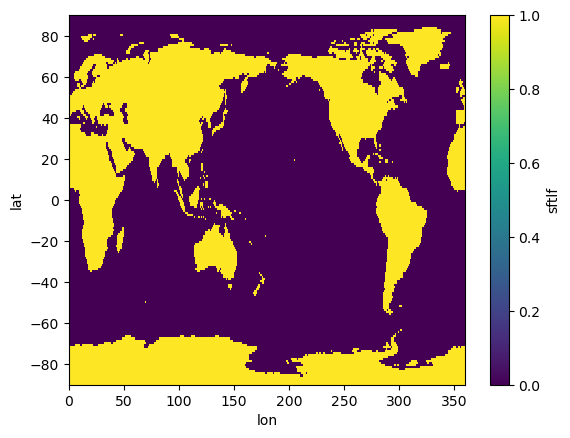

In [71]:
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
fixed_dir = os.path.join(outdir, "fixed")
os.makedirs(fixed_dir, exist_ok=True)

out_file = os.path.join(outdir,"fixed", "sftlf.E3SM.nc")

if not os.path.exists(out_file):
    da = e3smle11_seas[field]

    landmask = spatial.create_land_sea_mask(
        da,
        lat_key="lat",
        lon_key="lon",
    )

    landmask = landmask.astype("int8")   # 👈 key change
    landmask.name = "sftlf"

    landmask.to_netcdf(out_file)

else:
    landmask = xr.open_dataarray(out_file)
    
landmask.plot()
print(landmask)
print(landmask.dims)

In [72]:
# lon-w, lon-e, lat-s, lat-n
regionlonlat = [-170., -120., -5., 5.]
regiontitle = 'Nino3.4'

landmask = landmask.astype(bool)
oceanmask = ~landmask

# build weights once
e3sm_reg_ocean_area = data_access.e3sm_regional_weights(
    e3smle11_seas[field],
    regionlonlat,
    lat_name="lat",
    lon_name="lon",
    mask=oceanmask,
)

e3smle11_seas_ocean_reg = (
    e3smle11_seas[field]
    .weighted(e3sm_reg_ocean_area)
    .mean(("lat", "lon"))
    .load()
)

e3smle05_seas_ocean_reg = (
    e3smle05_seas[field]
    .weighted(e3sm_reg_ocean_area)
    .mean(("lat", "lon"))
    .load()
)

print(e3smle11_seas_ocean_reg)
print(e3smle11_seas_ocean_reg.dims)

print(e3smle05_seas_ocean_reg)
print(e3smle05_seas_ocean_reg.dims)

e3smle11_regsst = (
    e3smle11[field]
    .weighted(e3sm_reg_ocean_area)
    .mean(("lat", "lon"))
    .load()
)

e3smle05_regsst = (
    e3smle05[field]
    .weighted(e3sm_reg_ocean_area)
    .mean(("lat", "lon"))
    .load()
)

print(e3smle11_regsst)
print(e3smle11_regsst.dims)

print(e3smle05_regsst)
print(e3smle05_regsst.dims)

<xarray.DataArray 'TS' (Y: 4, L: 8, M: 10)> Size: 3kB
array([[[25.42300861, 25.58894615, 25.78229145, 25.86348704,
         25.55753928, 25.28070366, 26.03277787, 25.47968012,
         25.73530758, 25.85507389],
        [25.69400961, 26.4353892 , 25.60591923, 25.0997488 ,
         26.4174852 , 25.62388797, 26.40683653, 25.30662028,
         26.99645573, 26.65219067],
        [25.20293507, 25.30677661, 25.00225327, 23.33840883,
         25.94162537, 24.49353761, 25.13629829, 25.01369562,
         26.46876417, 25.77524878],
        [24.07178069, 23.83683958, 23.9791582 , 21.766167  ,
         24.94853446, 23.05531557, 23.52692334, 24.05429345,
         25.76433584, 23.12502986],
        [24.84054148, 24.12208439, 24.11290575, 22.7261596 ,
         24.35405375, 23.19269593, 24.58810641, 24.36154559,
         26.03458918, 23.24926985],
        [26.7604212 , 25.83823817, 26.2521165 , 25.87175292,
         25.45151313, 25.82155954, 26.42255045, 26.29872964,
         27.614389  , 24.64651147]

### Perform regional-average computation on SMYLE, returning xarray:

### Store datasets to disk for quicker processing next time 

In [73]:
%%time
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

force_rewrite = True

outfile05 = os.path.join(
    outdir,
    f"E3SMLE05_{field}_N{case_nens:02d}_M{case_nlead:02d}_Nino3.4SST_seas.nc"
)
outfile11 = os.path.join(
    outdir,
    f"E3SMLE11_{field}_N{case_nens:02d}_M{case_nlead:02d}_Nino3.4SST_seas.nc"
)

if os.path.exists(outfile05) and not force_rewrite:
    ds_e3smle05_seas_regsst = xr.open_dataset(outfile05)
else:
    if os.path.exists(outfile05):
        os.remove(outfile05)

    e3smle05_seas_time = e3smle05_seas.time.load()
    reg05 = e3smle05_seas_ocean_reg.rename("sst")
    ds_e3smle05_seas_regsst = reg05.to_dataset()
    ds_e3smle05_seas_regsst["time"] = e3smle05_seas_time
    ds_e3smle05_seas_regsst["sst"].attrs.update({
        "long_name": "Nino3.4 regional mean SST",
        "region": "Nino3.4",
        "lonlat": "[-170, -120, -5, 5]",
    })
    ds_e3smle05_seas_regsst.to_netcdf(outfile05)

if os.path.exists(outfile11) and not force_rewrite:
    ds_e3smle11_seas_regsst = xr.open_dataset(outfile11)
else:
    if os.path.exists(outfile11):
        os.remove(outfile11)

    e3smle11_seas_time = e3smle11_seas.time.load()
    reg11 = e3smle11_seas_ocean_reg.rename("sst")
    ds_e3smle11_seas_regsst = reg11.to_dataset()
    ds_e3smle11_seas_regsst["time"] = e3smle11_seas_time
    ds_e3smle11_seas_regsst["sst"].attrs.update({
        "long_name": "Nino3.4 regional mean SST",
        "region": "Nino3.4",
        "lonlat": "[-170, -120, -5, 5]",
    })
    ds_e3smle11_seas_regsst.to_netcdf(outfile11)

print(ds_e3smle11_seas_regsst)
print(ds_e3smle05_seas_regsst)

<xarray.Dataset> Size: 3kB
Dimensions:  (L: 8, Y: 4, M: 10)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * Y        (Y) <U10 160B '1980110100' '1981110100' '1982110100' '1983110100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 3kB 25.42 25.59 25.78 25.86 ... nan nan nan nan
    time     (Y, L) object 256B 1981-01-15 00:00:00 ... 1985-10-15 00:00:00
<xarray.Dataset> Size: 3kB
Dimensions:  (L: 8, Y: 4, M: 10)
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24
  * Y        (Y) <U10 160B '1980050100' '1981050100' '1982050100' '1983050100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 3kB 27.41 26.6 27.2 28.03 ... nan nan nan nan
    time     (Y, L) object 256B 1980-07-15 00:00:00 ... 1985-04-15 00:00:00
CPU times: user 134 ms, sys: 31.6 ms, total: 166 ms
Wall time: 175 ms


In [74]:
%%time
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE'
os.makedirs(outdir, exist_ok=True)

force_rewrite = True

outfile05 = os.path.join(
    outdir,
    f"E3SMLE05_{field}_N{case_nens:02d}_M{case_nlead:02d}_Nino3.4SST_mon.nc"
)
outfile11 = os.path.join(
    outdir,
    f"E3SMLE11_{field}_N{case_nens:02d}_M{case_nlead:02d}_Nino3.4SST_mon.nc"
)

if os.path.exists(outfile05) and not force_rewrite:
    ds_e3smle05_regsst = xr.open_dataset(outfile05)
else:
    if os.path.exists(outfile05):
        os.remove(outfile05)

    e3smle05_time = e3smle05.time.load()
    reg05_mon = e3smle05_regsst.rename("sst")
    ds_e3smle05_regsst = reg05_mon.to_dataset()
    ds_e3smle05_regsst["time"] = e3smle05_time
    ds_e3smle05_regsst["sst"].attrs.update({
        "long_name": "Nino3.4 regional mean SST",
        "region": "Nino3.4",
        "lonlat": "[-170, -120, -5, 5]",
    })
    ds_e3smle05_regsst.to_netcdf(outfile05)

if os.path.exists(outfile11) and not force_rewrite:
    ds_e3smle11_regsst = xr.open_dataset(outfile11)
else:
    if os.path.exists(outfile11):
        os.remove(outfile11)

    e3smle11_time = e3smle11.time.load()
    reg11_mon = e3smle11_regsst.rename("sst")
    ds_e3smle11_regsst = reg11_mon.to_dataset()
    ds_e3smle11_regsst["time"] = e3smle11_time
    ds_e3smle11_regsst["sst"].attrs.update({
        "long_name": "Nino3.4 regional mean SST",
        "region": "Nino3.4",
        "lonlat": "[-170, -120, -5, 5]",
    })
    ds_e3smle11_regsst.to_netcdf(outfile11)

print(ds_e3smle11_regsst)
print(ds_e3smle05_regsst)

<xarray.Dataset> Size: 9kB
Dimensions:  (L: 24, Y: 4, M: 10)
Coordinates:
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * Y        (Y) <U10 160B '1980110100' '1981110100' '1982110100' '1983110100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 8kB 26.37 26.39 26.37 26.39 ... 21.82 25.43 24.69
    time     (Y, L) object 768B 1980-11-15 00:00:00 ... 1985-10-15 00:00:00
<xarray.Dataset> Size: 9kB
Dimensions:  (L: 24, Y: 4, M: 10)
Coordinates:
  * L        (L) int64 192B 1 2 3 4 5 6 7 8 9 10 ... 16 17 18 19 20 21 22 23 24
  * Y        (Y) <U10 160B '1980050100' '1981050100' '1982050100' '1983050100'
  * M        (M) <U4 160B 'EN00' 'EN01' 'EN02' 'EN03' ... 'EN07' 'EN08' 'EN09'
Data variables:
    sst      (Y, L, M) float64 8kB 28.62 28.58 28.57 28.62 ... 25.1 25.7 25.56
    time     (Y, L) object 768B 1980-05-15 00:00:00 ... 1985-04-15 00:00:00
CPU times: user 177 ms, sys: 98.

In [75]:
## Retrieve pre-saved E3SM Fig data:
outdir = '/pscratch/sd/z/zhan391/e3sm_project/E3SMv3_S2D/s2d_diag/E3SMLE/'

ds_e3smle11_seas_regsst = xr.open_dataset(
    outdir + f'E3SMLE11_{field}_N{case_nens:02d}_M{case_nlead:02d}_Nino3.4SST_seas.nc'
)
e3smle11_seas_time = ds_e3smle11_seas_regsst['time']
e3smle11_seas_regsst = ds_e3smle11_seas_regsst['sst']

ds_e3smle05_seas_regsst = xr.open_dataset(
    outdir + f'E3SMLE05_{field}_N{case_nens:02d}_M{case_nlead:02d}_Nino3.4SST_seas.nc'
)
e3smle05_seas_time = ds_e3smle05_seas_regsst['time']
e3smle05_seas_regsst = ds_e3smle05_seas_regsst['sst']

ds_e3smle11_regsst = xr.open_dataset(
    outdir + f'E3SMLE11_{field}_N{case_nens:02d}_M{case_nlead:02d}_Nino3.4SST_mon.nc'
)
e3smle11_time = ds_e3smle11_regsst['time']
e3smle11_regsst = ds_e3smle11_regsst['sst']

ds_e3smle05_regsst = xr.open_dataset(
    outdir + f'E3SMLE05_{field}_N{case_nens:02d}_M{case_nlead:02d}_Nino3.4SST_mon.nc'
)
e3smle05_time = ds_e3smle05_regsst['time']
e3smle05_regsst = ds_e3smle05_regsst['sst']

### Compute observed monthly and seasonal anomalies

[OBS] Mapping field 'TS' -> 'sst'
[OBS] Loading: /global/cfs/cdirs/e3sm/diagnostics/observations/Atm/time-series/HadISST/sst_187001_201712.nc
<xarray.Dataset> Size: 118MB
Dimensions:  (time: 456, lat: 180, lon: 360)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float32 1kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
  * time     (time) object 4kB 1980-01-15 00:00:00 ... 2017-12-15 00:00:00
Data variables:
    sst      (time, lat, lon) float32 118MB dask.array<chunksize=(1, 180, 360), meta=np.ndarray>
Attributes: (12/13)
    CDI:                        Climate Data Interface version 1.6.8 (http://...
    history:                    Mon Mar 10 19:00:17 2025: ncks -C -x -v latit...
    source:                     HadISST
    institution:                Met Office Hadley Centre
    Conventions:                CF-1.0
    comment:                    Data restrictions: for academic research use ...
    ...                  

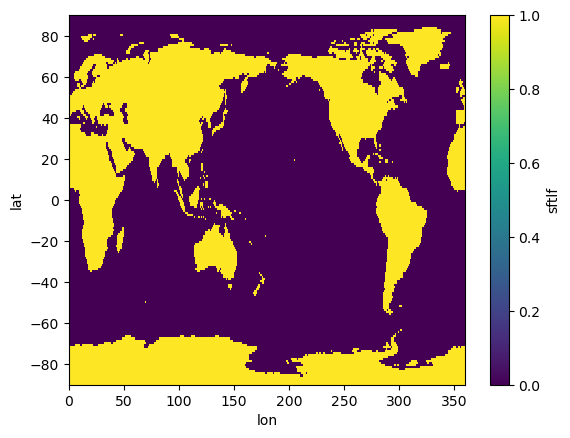

In [76]:
%%time
obs_dir = '/global/cfs/cdirs/e3sm/e3sm_diags/obs_for_e3sm_diags/time-series'
obs_product = "HadISST"  
obs_var = "sst"  
obs_yrs = 1870
obs_yre = 2017

obs_hadisst = obs_access.get_monthly_data(
    obs_dir=obs_dir,
    field=field,
    field_map={field: obs_var},
    product=obs_product,
    start_year=obs_yrs,
    end_year=obs_yre,
    verbose=True
)

# Apply value constraint
obs_hadisst[obs_var] = xr.where(
    obs_hadisst[obs_var] < -2,
    -1.8,
    obs_hadisst[obs_var]
)
# Time slice
obs_hadisst = obs_hadisst.sel(time=slice("1980", "2017"))

print(obs_hadisst)

#Compute OBS seasonal averages (simple rolling mean)
obs_hadisst_seas = obs_access.mon_to_seas_obs(
    obs_hadisst,
    var=obs_var,
    field_map={field: obs_var},
)

out_file = os.path.join(outdir,"fixed", f"sftlf.{obs_product}.nc")

if not os.path.exists(out_file):
    da = obs_hadisst_seas[field]
    landmasko = spatial.create_land_sea_mask(
        da,
        lat_key="lat",
        lon_key="lon",
    )
    landmasko = landmask.astype("int8") 
    landmasko.name = "sftlf"
    landmasko.to_netcdf(out_file)
else:
    landmasko = xr.open_dataarray(out_file)
    
landmasko.plot()
print(landmasko)
print(landmasko.dims)


In [77]:
landmasko = landmasko.astype(bool)
oceanmasko = ~landmasko

# build weights once for obs grid
obs_reg_ocean_area = obs_access.obs_regional_weights(
    obs_hadisst_seas,
    regionlonlat,
    lat_name="lat",
    lon_name="lon",
    mask=oceanmasko,
)

obs_seas = (
    obs_hadisst_seas
    .weighted(obs_reg_ocean_area)
    .mean(("lat", "lon"))
    .load()
)
print(obs_seas)

obs_mon = (
    obs_hadisst[obs_var]
    .weighted(obs_reg_ocean_area)
    .mean(("lat", "lon"))
    .load()
)

print(obs_mon)


<xarray.DataArray 'TS' (time: 454)> Size: 2kB
array([27.162298, 27.447248, 27.751606, 27.985764, 27.73901 , 27.283651,
       26.800505, 26.590643, 26.624357, 26.733244, 26.568693, 26.42445 ,
       26.526466, 27.026278, 27.51408 , 27.61479 , 27.340057, 26.982304,
       26.692722, 26.661057, 26.55623 , 26.544899, 26.494905, 26.582191,
       26.785587, 27.279755, 27.906967, 28.361732, 28.305239, 28.06624 ,
       27.90648 , 28.199053, 28.508026, 28.775475, 28.87458 , 28.966366,
       28.980522, 28.944958, 28.94563 , 28.72511 , 28.120956, 27.36743 ,
       26.677567, 26.204275, 25.791061, 25.584032, 25.614443, 25.85753 ,
       26.247513, 26.717072, 27.050205, 27.047703, 26.923544, 26.66919 ,
       26.53613 , 26.226315, 25.889856, 25.440105, 25.371284, 25.499363,
       25.921507, 26.29471 , 26.670135, 26.878534, 26.816269, 26.61621 ,
       26.361433, 26.182507, 26.12682 , 26.12842 , 26.030127, 26.000397,
       26.196579, 26.728539, 27.155758, 27.439117, 27.438076, 27.337852,
     

# Skill Analysis

In [80]:
%%time
# Remove lead-time-dependent climatology
climy0 = 1980
climy1 = 1983

# --- 11 ---
e3smle11_seas_regsst_dd, e3smle11_seas_regsst_drift = stats.remove_drift(
    e3smle11_seas_regsst,
    e3smle11_seas_time,
    climy0,
    climy1,
)

e3smle11_regsst_dd, e3smle11_regsst_drift = stats.remove_drift(
    e3smle11_regsst,
    e3smle11_time,
    climy0,
    climy1,
)

# --- 05 ---
e3smle05_seas_regsst_dd, e3smle05_seas_regsst_drift = stats.remove_drift(
    e3smle05_seas_regsst,
    e3smle05_seas_time,
    climy0,
    climy1,
)

e3smle05_regsst_dd, e3smle05_regsst_drift = stats.remove_drift(
    e3smle05_regsst,
    e3smle05_time,
    climy0,
    climy1,
)

CPU times: user 21.1 ms, sys: 12.8 ms, total: 33.9 ms
Wall time: 29.1 ms


In [82]:
%%time
# --- Monthly skill ---
e3smle11_skill = stats.compute_skill_seasonal(
    e3smle11_regsst_dd,
    e3smle11_time,
    obs_mon,
    str(climy0),
    str(climy1),
    1,
    24,
    resamp=0,
    detrend=True,
    monthly=True,
)

e3smle05_skill = stats.compute_skill_seasonal(
    e3smle05_regsst_dd,
    e3smle05_time,
    obs_mon,
    str(climy0),
    str(climy1),
    1,
    24,
    resamp=0,
    detrend=True,
    monthly=True,
)

# --- Seasonal skill ---
e3smle11_seas_skill = stats.compute_skill_seasonal(
    e3smle11_seas_regsst_dd,
    e3smle11_seas_time,
    obs_seas,
    str(climy0),
    str(climy1),
    1,
    8,
    resamp=0,
    detrend=True,
)

e3smle05_seas_skill = stats.compute_skill_seasonal(
    e3smle05_seas_regsst_dd,
    e3smle05_seas_time,
    obs_seas,
    str(climy0),
    str(climy1),
    1,
    8,
    resamp=0,
    detrend=True,
)

/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:415: RuntimeWarning: invalid value encountered in scalar divide
  _x = dof / (dof + t_squared)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:415: RuntimeWarning: invalid value encountered in scalar divide
  _x = dof / (dof + t_squared)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:415: RuntimeWarning: invalid value encountered in scalar divide
  _x = dof / (dof + t_squared)
/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:415: RuntimeWarning: invalid value encountered in scalar divide
  _x = dof / (dof + t_squared)


CPU times: user 2.05 s, sys: 577 ms, total: 2.63 s
Wall time: 2.32 s


/global/homes/z/zhan391/.local/lib/python3.10/site-packages/xskillscore/core/np_deterministic.py:415: RuntimeWarning: invalid value encountered in scalar divide
  _x = dof / (dof + t_squared)


# Plots

In [83]:
# combine skill score xarrays for plotting
startmonth = xr.DataArray([5, 11], name='startmonth', dims='startmonth')
# seasonal
e3smle_seas_skill = xr.concat(
    [
        e3smle05_seas_skill,
        e3smle11_seas_skill,
    ],
    dim=startmonth
)

# monthly
e3smle_skill = xr.concat(
    [
        e3smle05_skill,
        e3smle11_skill,
    ],
    dim=startmonth
)

In [84]:
e3smle_seas_skill.L

<xarray.DataArray 'L' (L: 8)> Size: 64B
array([ 3,  6,  9, 12, 15, 18, 21, 24])
Coordinates:
  * L        (L) int64 64B 3 6 9 12 15 18 21 24

### Figure 3

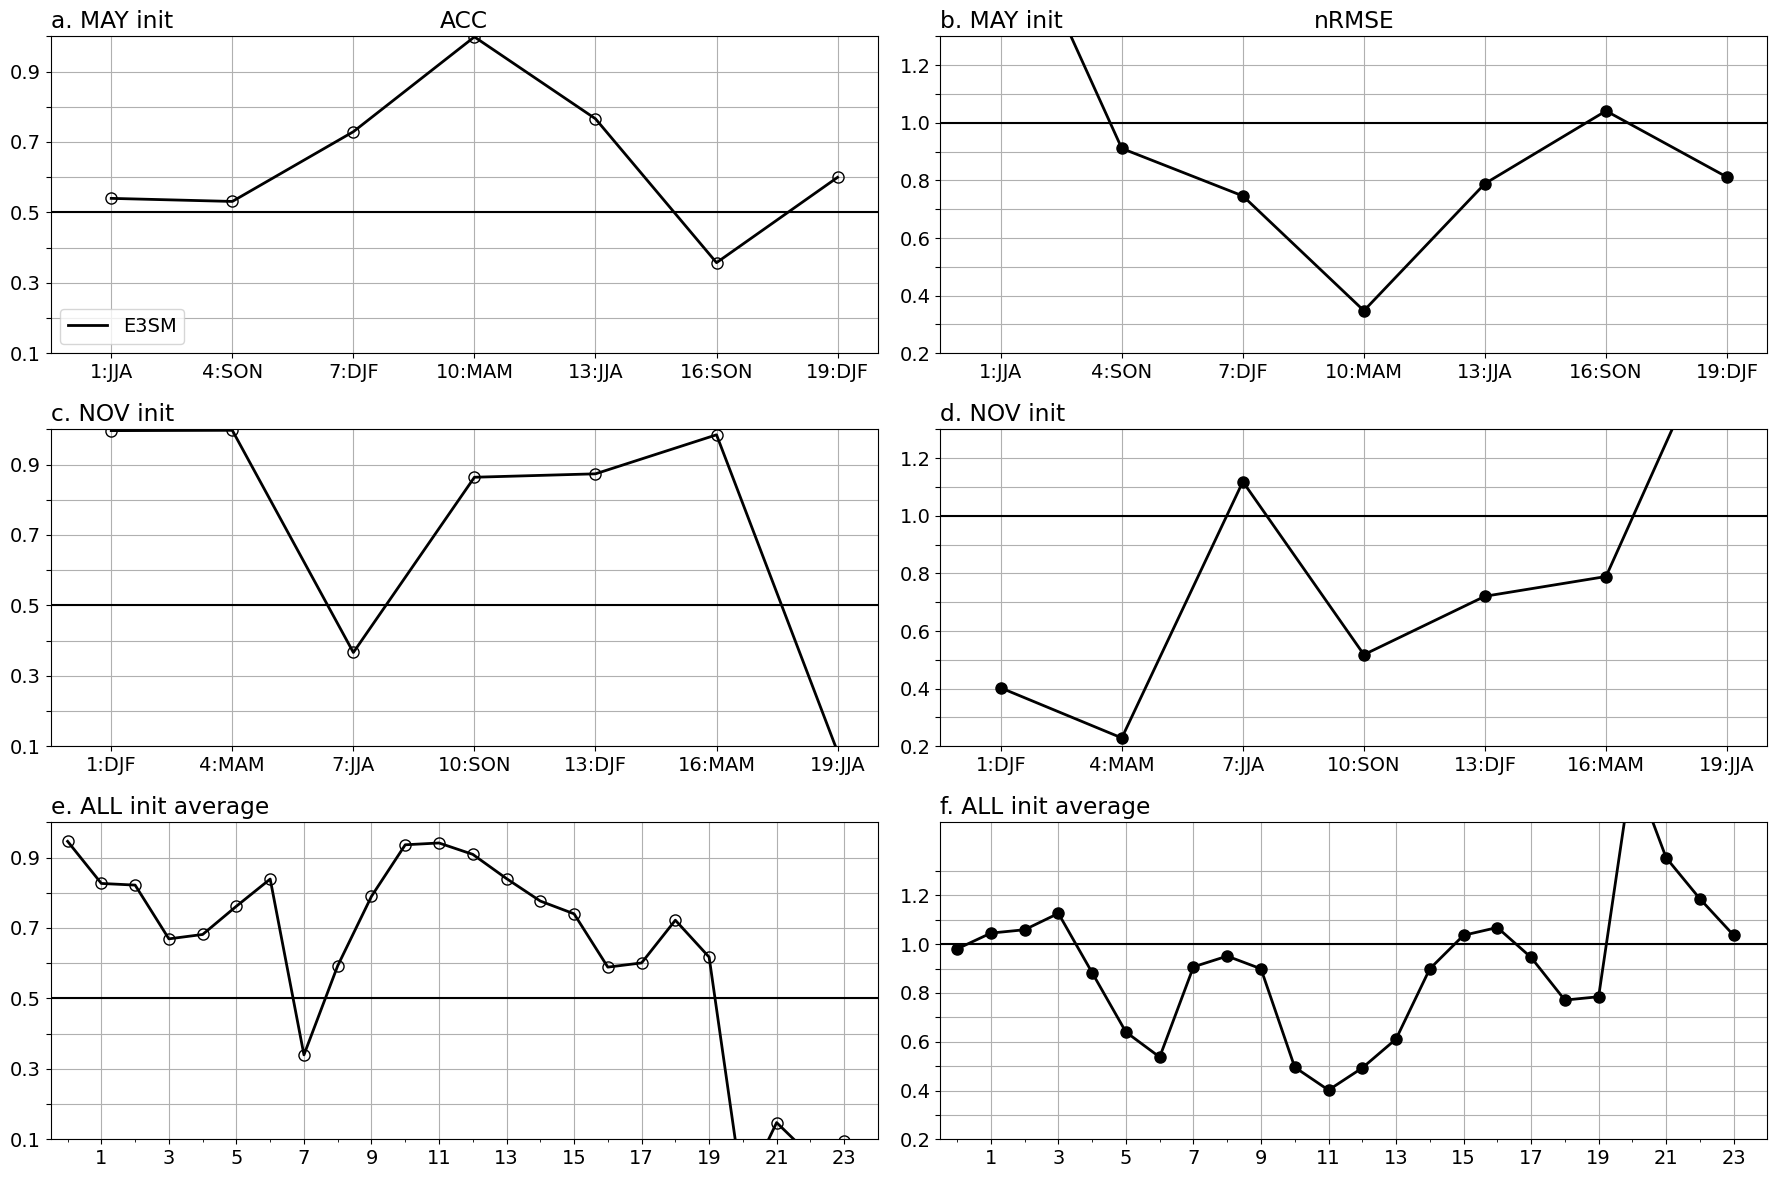

In [86]:
# plot E3SM skill scores
fig = plt.figure(figsize=(18, 12))
plt.rcParams['font.size'] = '14'

leadsea = e3smle_seas_skill.L[0:-1] - 2
leadmon = e3smle_skill.L - 1

# seasonal lead labels for May and Nov starts
xsea = {
    5:  ['JJA', 'SON', 'DJF', 'MAM', 'JJA', 'SON', 'DJF'],
    11: ['DJF', 'MAM', 'JJA', 'SON', 'DJF', 'MAM', 'JJA'],
}

hindcasts = ['MAY init', 'NOV init', 'ALL init average']
figlabs = [['a.', 'c.', 'e.'], ['b.', 'd.', 'f.']]

ncol = 2
nrow = 3
startmonths = [5, 11]

# -------------------------
# top 2 rows: individual starts
# -------------------------
for j, sm in enumerate(startmonths):
    ax = fig.add_subplot(nrow, ncol, j * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, j * 2 + 2)

    ax.set_title(figlabs[0][j] + ' ' + hindcasts[j], loc='left')
    ax2.set_title(figlabs[1][j] + ' ' + hindcasts[j], loc='left')

    if j == 0:
        ax.set_title('ACC', loc='center')
        ax2.set_title('nRMSE', loc='center')

    # seasonal skill
    tmp = e3smle_seas_skill.sel(startmonth=sm)

    ax.plot(tmp.L - 2, tmp.corr, color='k', linewidth=2, label='E3SM')
    ax.plot(tmp.L - 2, tmp.corr, color='k', marker='o', markersize=8, fillstyle='none', linestyle='none')
    ax.plot(tmp.L - 2, tmp.corr.where(tmp.pval < 0.1), color='k', marker='o', markersize=8, linestyle='none')

    ax2.plot(tmp.L - 2, tmp.rmse, color='k', linewidth=2, marker='o', markersize=8)

    ax.set_xticks(leadsea)
    xticklabs = [f"{int(leadsea[i].data)}:{xsea[sm][i]}" for i in range(leadsea.sizes['L'])]
    ax.set_xticklabels(xticklabs)
    ax.set_yticks(np.arange(10) * 0.1 + 0.1)
    ax.set_yticklabels(['0.1', '', '0.3', '', '0.5', '', '0.7', '', '0.9', ''])
    ax.set_xlim([-0.5, 20])
    ax.set_ylim([0.1, 1.0])
    ax.grid(True)
    ax.axhline(y=0.5, color='black')

    if j == 0:
        ax.legend(loc='lower left')

    ax2.set_xticks(leadsea)
    ax2.set_xticklabels(xticklabs)
    ax2.set_yticks(np.arange(12) * 0.1 + 0.2)
    ax2.set_yticklabels(['0.2', '', '0.4', '', '0.6', '', '0.8', '', '1.0', '', '1.2', ''])
    ax2.set_xlim([-0.5, 20])
    ax2.set_ylim([0.2, 1.3])
    ax2.grid(True)
    ax2.axhline(y=1.0, color='black')

# -------------------------
# bottom row: average of May and Nov, monthly skill
# -------------------------
ax = fig.add_subplot(nrow, ncol, 3 * 2 - 1)
ax2 = fig.add_subplot(nrow, ncol, 3 * 2)

ax.set_title(figlabs[0][2] + ' ' + hindcasts[2], loc='left')
ax2.set_title(figlabs[1][2] + ' ' + hindcasts[2], loc='left')

tmp = e3smle_skill.mean('startmonth')

ax.plot(tmp.L - 1, tmp.corr, color='k', linewidth=2)
ax.plot(tmp.L - 1, tmp.corr, color='k', marker='o', markersize=8, fillstyle='none', linestyle='none')
ax.plot(tmp.L - 1, tmp.corr.where(tmp.pval < 0.1), color='k', marker='o', markersize=8, linestyle='none')

ax2.plot(tmp.L - 1, tmp.rmse, color='k', linewidth=2, marker='o', markersize=8)

ax.set_xticks(np.arange(12) * 2 + 1)
ax.set_xticks(np.arange(12) * 2, minor=True)
ax.set_yticks(np.arange(10) * 0.1 + 0.1)
ax.set_yticklabels(['0.1', '', '0.3', '', '0.5', '', '0.7', '', '0.9', ''])
ax.set_xlim([-0.5, 24])
ax.set_ylim([0.1, 1.0])
ax.grid(True)
ax.axhline(y=0.5, color='black')

ax2.set_xticks(np.arange(12) * 2 + 1)
ax2.set_xticks(np.arange(12) * 2, minor=True)
ax2.set_yticks(np.arange(12) * 0.1 + 0.2)
ax2.set_yticklabels(['0.2', '', '0.4', '', '0.6', '', '0.8', '', '1.0', '', '1.2', ''])
ax2.set_xlim([-0.5, 24])
ax2.set_ylim([0.2, 1.5])
ax2.grid(True)
ax2.axhline(y=1.0, color='black')

fig.tight_layout()
plt.savefig('e3sm_skill.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 4

In [89]:
print(obs_seas.time)

<xarray.DataArray 'time' (time: 454)> Size: 4kB
array([cftime.DatetimeNoLeap(1980, 2, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1980, 3, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(1980, 4, 15, 0, 0, 0, 0, has_year_zero=True), ...,
       cftime.DatetimeNoLeap(2017, 9, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2017, 10, 15, 0, 0, 0, 0, has_year_zero=True),
       cftime.DatetimeNoLeap(2017, 11, 15, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
  * time     (time) object 4kB 1980-02-15 00:00:00 ... 2017-11-15 00:00:00


In [90]:
jan = obs_seas.time.dt.month==1
obs_djf = obs_seas.where(jan).dropna('time')
obs_djf = obs_djf - obs_djf.sel(time=slice("1980","1985")).mean('time')

In [93]:
# combine skill score xarrays for plotting
startmonth = xr.DataArray([11, 5], name='startmonth', dims='startmonth')
e3smle_seas_skill = xr.concat(
    [e3smle11_seas_skill, e3smle05_seas_skill],
    dim=startmonth
)
e3smle_seas = xr.concat(
    [e3smle11_seas_regsst_dd, e3smle05_seas_regsst_dd],
    dim=startmonth
)
e3smle_seas_time = xr.concat(
    [e3smle11_seas_time, e3smle05_seas_time],
    dim=startmonth
)

tmp_time = e3smle_seas_time.isel(startmonth=i).isel(L=Lindex)
print(tmp_time)
print(tmp_time.dtype)

<xarray.DataArray 'time' (Y: 8)> Size: 64B
array([nan,
       cftime.DatetimeNoLeap(1981, 1, 15, 0, 0, 0, 0, has_year_zero=True),
       nan,
       cftime.DatetimeNoLeap(1982, 1, 15, 0, 0, 0, 0, has_year_zero=True),
       nan,
       cftime.DatetimeNoLeap(1983, 1, 15, 0, 0, 0, 0, has_year_zero=True),
       nan,
       cftime.DatetimeNoLeap(1984, 1, 15, 0, 0, 0, 0, has_year_zero=True)],
      dtype=object)
Coordinates:
    L           int64 8B 3
  * Y           (Y) <U10 320B '1980050100' '1980110100' ... '1983110100'
    startmonth  int64 8B 11
object


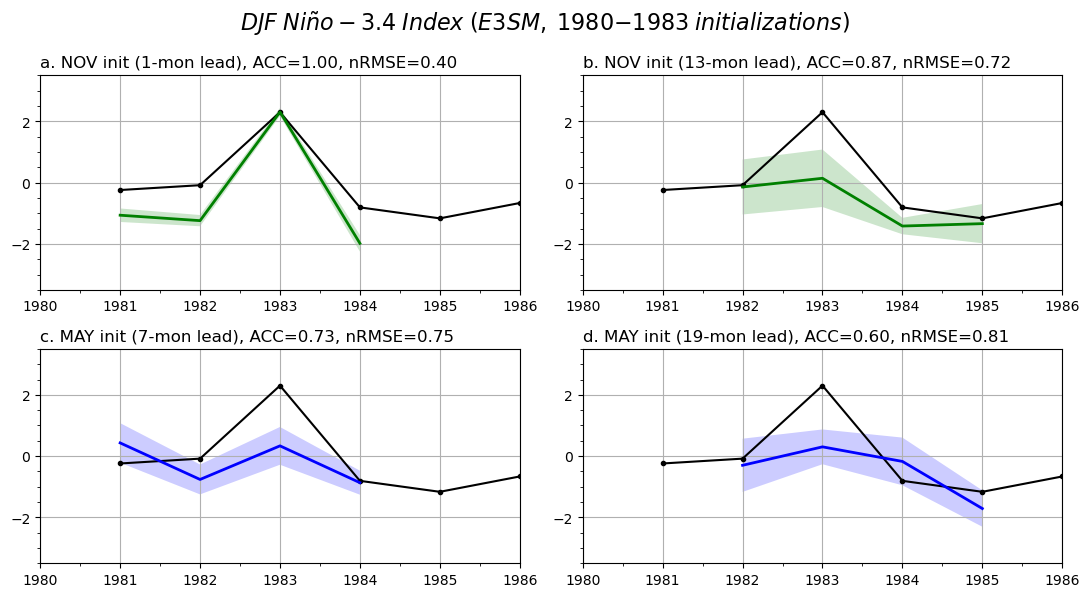

In [96]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(10 * 1.1, 5.5 * 1.1))

nrow = 2
ncol = 2
plt.rcParams.update({'font.size': 10})

# Adjust these if your startmonth order is different
hindcasts = ['NOV', 'MAY']
colors = ['g', 'b']
figlabs = [['a.', 'c.'], ['b.', 'd.']]

# For DJF target:
# NOV init -> first DJF seasonal lead
# MAY init -> third DJF seasonal lead
djfleadindex = [0, 2]

plot_xmin = 1980
plot_xmax = 1986

# Detect ensemble/member dimension
if 'M' in e3smle_seas.dims:
    member_dim = 'M'
elif 'member' in e3smle_seas.dims:
    member_dim = 'member'
else:
    member_dim = None

for i in range(nrow):
    ax = fig.add_subplot(nrow, ncol, i * 2 + 1)
    ax2 = fig.add_subplot(nrow, ncol, i * 2 + 2)

    for a in [ax, ax2]:
        a.set_ylim([-3.5, 3.5])
        a.set_yticks([-2, 0, 2])
        a.set_yticks(np.arange(-3.5, 4, 0.5), minor=True)
        a.set_xlim([plot_xmin, plot_xmax])
        a.set_xticks(np.arange(plot_xmin, plot_xmax + 1, 1))
        a.set_xticks(np.arange(plot_xmin, plot_xmax + 0.5, 0.5), minor=True)
        a.plot(obs_djf.time.dt.year, obs_djf, color='k', marker='.', markersize=6)
        a.grid(True)

    # -------------------------
    # Left panel
    # -------------------------
    Lindex = djfleadindex[i]

    lead = e3smle_seas.isel(startmonth=i).isel(L=Lindex).L.values.item() - 2
    acc = e3smle_seas_skill.isel(startmonth=i).isel(L=Lindex).corr.values.item()
    nrmse = e3smle_seas_skill.isel(startmonth=i).isel(L=Lindex).rmse.values.item()

    data = e3smle_seas.isel(startmonth=i).isel(L=Lindex)
    tmp_time = e3smle_seas_time.isel(startmonth=i).isel(L=Lindex)

    datatime = np.array([
        t.year if hasattr(t, "year") else np.nan
        for t in tmp_time.values
    ])
    valid = np.isfinite(datatime)

    datatime_plot = datatime[valid]
    data_plot = data.isel(Y=valid)

    titl = f"{hindcasts[i]} init ({int(lead)}-mon lead), ACC={acc:3.2f}, nRMSE={nrmse:3.2f}"
    ax.set_title(figlabs[0][i] + ' ' + titl, loc='left')

    if member_dim is not None:
        datamean = data_plot.mean(member_dim)
        datastd = data_plot.std(member_dim)
    else:
        datamean = data_plot
        datastd = xr.zeros_like(data_plot)

    ax.plot(datatime_plot, datamean, color=colors[i], linewidth=2)
    ax.fill_between(
        datatime_plot,
        (datamean - datastd).values,
        (datamean + datastd).values,
        fc=colors[i],
        alpha=0.2,
    )

    # -------------------------
    # Right panel
    # -------------------------
    Lindex = djfleadindex[i] + 4

    lead = e3smle_seas.isel(startmonth=i).isel(L=Lindex).L.values.item() - 2
    acc = e3smle_seas_skill.isel(startmonth=i).isel(L=Lindex).corr.values.item()
    nrmse = e3smle_seas_skill.isel(startmonth=i).isel(L=Lindex).rmse.values.item()

    data = e3smle_seas.isel(startmonth=i).isel(L=Lindex)
    tmp_time = e3smle_seas_time.isel(startmonth=i).isel(L=Lindex)

    datatime = np.array([
        t.year if hasattr(t, "year") else np.nan
        for t in tmp_time.values
    ])
    valid = np.isfinite(datatime)

    datatime_plot = datatime[valid]
    data_plot = data.isel(Y=valid)

    titl = f"{hindcasts[i]} init ({int(lead)}-mon lead), ACC={acc:3.2f}, nRMSE={nrmse:3.2f}"
    ax2.set_title(figlabs[1][i] + ' ' + titl, loc='left')

    if member_dim is not None:
        datamean = data_plot.mean(member_dim)
        datastd = data_plot.std(member_dim)
    else:
        datamean = data_plot
        datastd = xr.zeros_like(data_plot)

    ax2.plot(datatime_plot, datamean, color=colors[i], linewidth=2)
    ax2.fill_between(
        datatime_plot,
        (datamean - datastd).values,
        (datamean + datastd).values,
        fc=colors[i],
        alpha=0.2,
    )

fig.suptitle(r'$DJF\;Ni\tilde{n}o-3.4\;Index\;(E3SM,\;1980\mathrm{-}1983\;initializations)$', fontsize=16)
fig.tight_layout()
plt.savefig('e3sm_djf_nino34_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()